Shape before model prep: (79853, 20)
before
   perc_premium_paid_by_cash_credit  age_in_days    Income  \
0                             0.429      12058.0  355060.0   
1                             0.010      21546.0  315150.0   
2                             0.917      17531.0   84140.0   
3                             0.049      15341.0  250510.0   
4                             0.052      31400.0  198680.0   

   Count_3-6_months_late  Count_6-12_months_late  \
0                    0.0                     0.0   
1                    0.0                     0.0   
2                    2.0                     3.0   
3                    0.0                     0.0   
4                    0.0                     0.0   

   Count_more_than_12_months_late  application_underwriting_score  \
0                             0.0                           99.02   
1                             0.0                           99.89   
2                             1.0                           98.

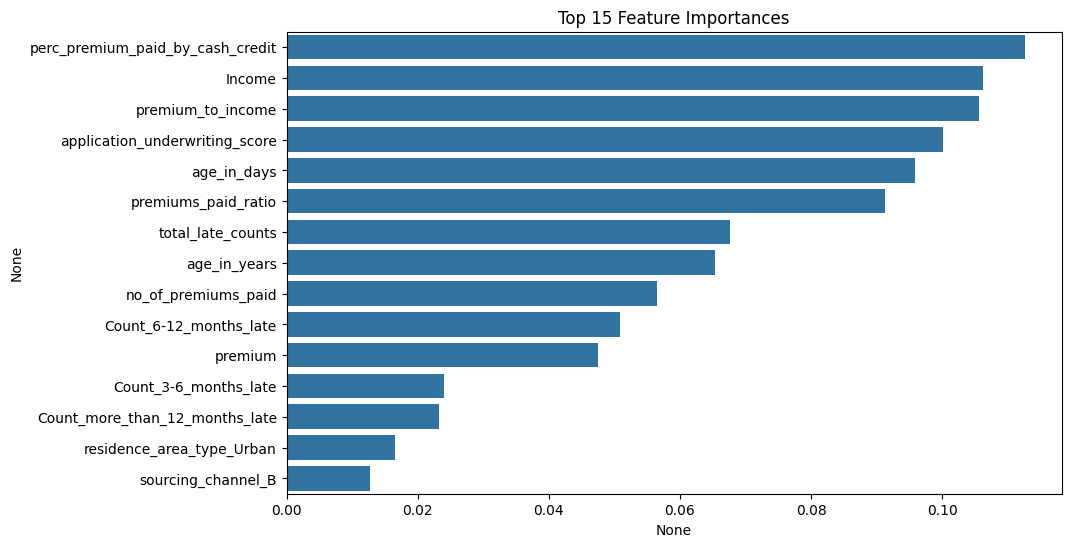

✅ Final model input files saved:
 - Train X: ..\data\train_X.csv
 - Test X: ..\data\test_X.csv
 - Train y: ..\data\train_y.csv
 - Test y: ..\data\test_y.csv


In [10]:
# 03_model_input_preparation.ipynb

# -------------------------------
# Step 1: Import libraries
# -------------------------------
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
INPUT_PATH = Path("../data/engineered_data.csv")
OUTPUT_TRAIN_PATH = Path("../data/train_X.csv")
OUTPUT_TEST_PATH = Path("../data/test_X.csv")
OUTPUT_TRAIN_Y_PATH = Path("../data/train_y.csv")
OUTPUT_TEST_Y_PATH = Path("../data/test_y.csv")

# -------------------------------
# Step 2: Load dataset
# -------------------------------
df = pd.read_csv(INPUT_PATH)
print("Shape before model prep:", df.shape)
df.head()

# -------------------------------
# Step 3: Separate features & target
# -------------------------------
X = df.drop(columns=["renewal"])
y = df["renewal"]

# -------------------------------
# Step 4: Scale numerical features
# -------------------------------
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print ('before')
print (X[numeric_cols].head())

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print ('after')
print (X[numeric_cols].head())
X.head()

# -------------------------------
# Step 5: Feature selection (RandomForest importance)
# -------------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x=importances.head(15), y=importances.head(15).index)
plt.title("Top 15 Feature Importances")
plt.show()

# Keep top features (optional threshold: top 20)
top_features = importances.head(20).index.tolist()
X = X[top_features]

# -------------------------------
# Step 6: Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# Step 7: Save final datasets
# -------------------------------
X_train.to_csv(OUTPUT_TRAIN_PATH, index=False)
X_test.to_csv(OUTPUT_TEST_PATH, index=False)
y_train.to_csv(OUTPUT_TRAIN_Y_PATH, index=False)
y_test.to_csv(OUTPUT_TEST_Y_PATH, index=False)

print("✅ Final model input files saved:")
print(" - Train X:", OUTPUT_TRAIN_PATH)
print(" - Test X:", OUTPUT_TEST_PATH)
print(" - Train y:", OUTPUT_TRAIN_Y_PATH)
print(" - Test y:", OUTPUT_TEST_Y_PATH)
